# Exercise 1
Outlier removal by percentile boundation


This cell imports necessary libraries like pandas for data manipulation, numpy for numerical operations, matplotlib and seaborn for plotting, and sets up warning suppression.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

This cell loads the `AB_NYC_2019.csv` dataset into a pandas DataFrame called `df` and then displays a summary of its structure, including column names, non-null counts, and data types.

In [25]:
df = pd.read_csv("/content/AB_NYC_2019.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

This cell provides descriptive statistics (count, mean, standard deviation, min, max, and quartiles) for the 'price' column in the `df` DataFrame.

In [26]:
df['price'].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


This cell checks if there are any missing (NaN) values in the 'price' column and sums them up. The output `np.int64(0)` indicates no missing values.

In [27]:
df['price'].isna().sum()

np.int64(0)

This cell checks if there is *at least one* missing value in the 'price' column. The output `np.False_` confirms there are no missing values.

In [28]:
df['price'].isna().any()

np.False_

This cell prints the minimum and maximum values found in the 'price' column of the `df` DataFrame.

In [29]:
print(f"Minimum price: {df['price'].min()}")
print(f"Maximum price: {df['price'].max()}")

Minimum price: 0
Maximum price: 10000


This cell sorts the DataFrame `df` by the 'price' column in ascending order and assigns it to `df_sorted_by_price`. It then displays the first 30 rows to show the lowest prices.

In [30]:
df_sorted_by_price = df.sort_values(by='price')
display(df_sorted_by_price.head(30))

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
26866,21304320,Best Coliving space ever! Shared room.,101970559,Sergii,Brooklyn,Bushwick,40.69166,-73.90928,Shared room,0,30,5,2019-05-24,0.26,6,139
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaN,NaN,1,0
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232


This cell extracts all unique values from the 'price' column, sorts them, and then prints the five smallest and five largest unique prices to understand the price range.

In [31]:
unique_prices = df['price'].sort_values().unique()

print("Five smallest unique prices:")
print(unique_prices[:5])

print("\nFive largest unique prices:")
print(unique_prices[-5:])

Five smallest unique prices:
[ 0 10 11 12 13]

Five largest unique prices:
[ 7703  8000  8500  9999 10000]


This cell re-calculates and displays the descriptive statistics for the 'price' column of the `df_sorted_by_price` DataFrame. This serves as a check and confirms the distribution after sorting.

In [32]:
df_sorted_by_price['price'].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


This cell calculates the 99th percentile of the 'price' column. This value is often used as an upper bound for outlier removal, considering prices above it as outliers.

In [33]:
percent_99 = df_sorted_by_price['price'].quantile(0.99)
percent_99

np.float64(799.0)

This cell displays the number of rows and columns in the original `df` DataFrame.

In [34]:
df.shape

(48895, 16)

This cell filters `df_sorted_by_price` to keep only rows where the 'price' is less than or equal to the 99th percentile (`percent_99`). It then shows the new shape of this filtered DataFrame, effectively removing high-end outliers.

In [35]:
df_no = df_sorted_by_price[df_sorted_by_price.price<= percent_99]
df_no.shape

(48421, 16)

This cell calculates the 1st percentile of the 'price' column. This value is often used as a lower bound for outlier removal, considering prices below it as outliers.

In [36]:
percent_01 = df_sorted_by_price['price'].quantile(0.01)
percent_01

np.float64(30.0)

This text cell indicates that the following code will create a new dataset after applying specific conditions for outlier removal.

## new dataset after the aplyig of the condition equation


This cell creates a new DataFrame `df1` by filtering `df_sorted_by_price` to include only prices between the 1st percentile (`percent_01`) and the 99th percentile (`percent_99`). This removes both very low and very high outliers. It then displays the shape of the new DataFrame.

In [37]:
df1 = df_sorted_by_price[(df_sorted_by_price.price<= percent_99) & (df_sorted_by_price.price>=percent_01)]
df1.shape

(48017, 16)

This cell displays the descriptive statistics for the 'price' column of the `df1` DataFrame. Notice the adjusted min and max values after outlier removal.

In [38]:
df1['price'].describe()

,price
count,48017.000000
mean,138.502010
std,103.694011
min,30.000000
25%,70.000000
50%,105.000000
75%,175.000000
max,799.000000


This is an empty text cell, likely a placeholder or remnant.

This is a text cell introducing 'Exercise 2', indicating a new section or task.

##Exercise 2


This cell loads a different dataset, `Bengaluru_House_Data.csv`, into a DataFrame named `df2` and displays its information, including column names, non-null counts, and data types.

In [39]:
df2 = pd.read_csv("/content/Bengaluru_House_Data.csv")
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


This cell calculates the 1st and 99th percentiles for the 'price' column in `df2`. These values (`min_thersold`, `max_thersold`) will be used for outlier removal in this new dataset.

In [43]:
min_thersold = df2['price'].quantile(0.01)
max_thersold = df2['price'].quantile(0.99)
min_thersold , max_thersold

(np.float64(18.5), np.float64(658.0999999999949))

This cell calculates and displays the count of missing values (`isna().sum()`) for each column in the `df2` DataFrame. This helps in understanding data quality.

In [41]:
df2.isna().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


This text cell explicitly states that the following operations are for 'outlier removal by percentile boundation' in the new dataset.

## outlier removal by percentile boundation

This cell creates a new DataFrame `df_n` by filtering `df2` to include 'price' values between `min_thersold` (1st percentile) and `max_thersold` (99th percentile). It then shows the shape of this filtered DataFrame.

In [45]:
df_n = df2[(df2.price>= min_thersold) & (df2.price<= max_thersold)]
df_n.shape

(13056, 9)

This cell calculates and displays the standard deviation of the 'price' column in the `df_n` DataFrame. This value is used later for z-score based outlier detection.

In [46]:
std_devi = df_n['price'].std()
std_devi

90.36702104401417

This cell calculates the mean of the 'price' column in `df_n`. This value is also used for z-score based outlier detection.

In [48]:
mean = df_n['price'].mean()

This cell calculates an upper bound (`r`) for outlier detection by adding 4 times the standard deviation to the mean of the 'price' column in `df_n`.

In [55]:
r = mean + 4*std_devi

This cell calculates a lower bound (`s`) for outlier detection by subtracting 4 times the standard deviation from the mean of the 'price' column in `df_n`.

In [56]:
s = mean - 4*std_devi

This cell displays the calculated lower bound `s`.

In [59]:
s

np.float64(-258.4326958488508)

This cell creates a new DataFrame `df_no` by filtering `df_n` to include 'price' values within the calculated `s` and `r` bounds (mean ± 4 standard deviations). It then displays the shape of this more strictly filtered DataFrame.

In [57]:
df_no = df_n[(df_n.price>= s)& (df_n.price<= r)]
df_no.shape

(12901, 9)

This cell generates a histogram of the 'price' column in `df_no` with a Kernel Density Estimate (KDE) overlay. It sets a title, x-axis label, and y-axis label to visualize the distribution of prices.

Text(0, 0.5, 'Frequency')

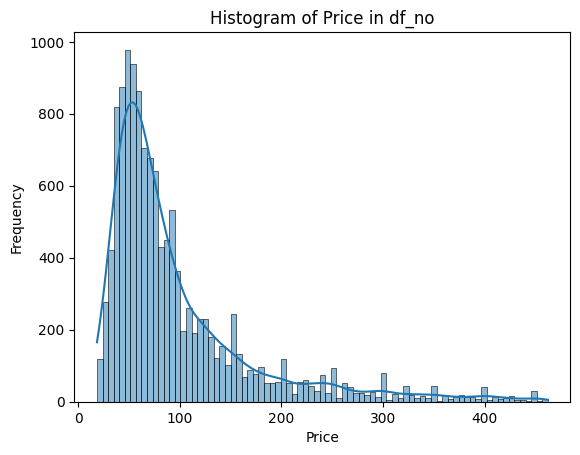

In [60]:
sns.histplot(df_no['price'], kde=True)
plt.title('Histogram of Price in df_no')
plt.xlabel('Price')
plt.ylabel('Frequency')

This cell generates another histogram of the 'price' column in `df_no` with a Kernel Density Estimate (KDE) overlay. It sets a more descriptive title, 'Distribution of Price (Bell Curve approximation) in df_no', and labels the axes as 'Price' and 'Density'. This is a refined version of the previous plot.

Text(0, 0.5, 'Density')

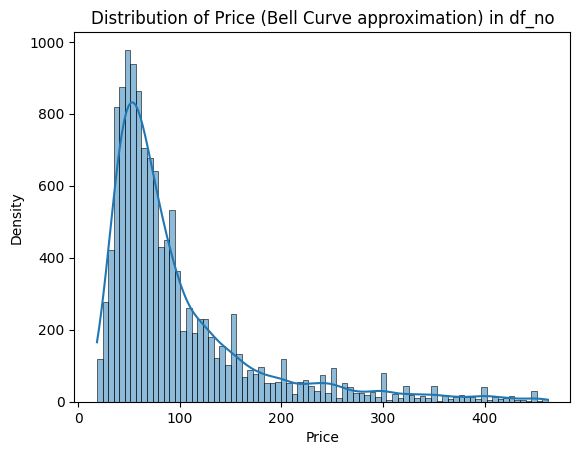

In [61]:
sns.histplot(df_no['price'], kde=True)
plt.title('Distribution of Price (Bell Curve approximation) in df_no')
plt.xlabel('Price')
plt.ylabel('Density')

This cell calculates the mean ('x') of the 'price' column from `df_n` and the standard deviation ('y') of the 'price' column from the original `df`. It then calculates the z-score for the 'price' column in `df_n` using these values and adds it as a new column named 'zscore'.

In [62]:
x = df_n['price'].mean()
y= df['price'].std()
df_n['zscore']=(df['price']- x)/y

This cell creates a new DataFrame `df_new` by filtering `df_n` to include only rows where the 'zscore' of 'price' is between -4 and 4. This is another method of outlier removal based on standard deviations. It then shows the shape of `df_new`.

In [63]:
df_new = df_n[(df_n.zscore<4) & (df_n.zscore>-4)]
df_new.shape

(12986, 10)

This cell generates a histogram of the 'price' column in the `df_new` DataFrame, which was filtered using z-scores. It includes a KDE, a title, and axis labels to visualize the distribution after this specific outlier removal step.

Text(0, 0.5, 'Density')

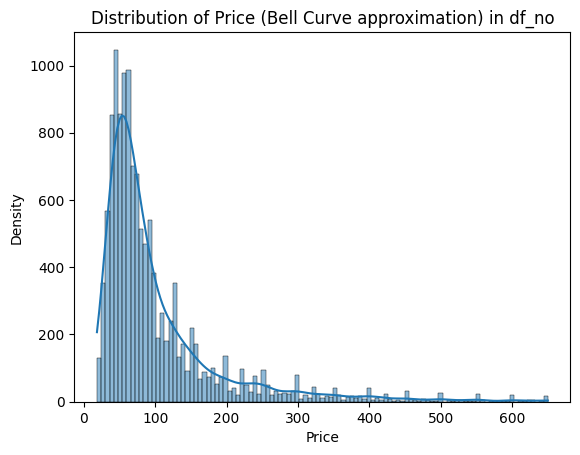

In [64]:
sns.histplot(df_new['price'], kde=True)
plt.title('Distribution of Price (Bell Curve approximation) in df_no')
plt.xlabel('Price')
plt.ylabel('Density')

This cell creates another `df_new` DataFrame, this time by applying a stricter z-score filter, keeping only values between -0.5 and 0.5. This will significantly narrow down the data. It then shows the shape of this very tightly filtered DataFrame.

In [85]:
df_new = df_n[(df_n.zscore<0.5) & (df_n.zscore>-0.5)]
df_new.shape

(11089, 10)

This cell generates a histogram of the 'price' column from the `df_new` DataFrame that was filtered with a z-score between -0.5 and 0.5. It includes a KDE, title, and axis labels to show the distribution with very strict outlier removal.

Text(0, 0.5, 'Density')

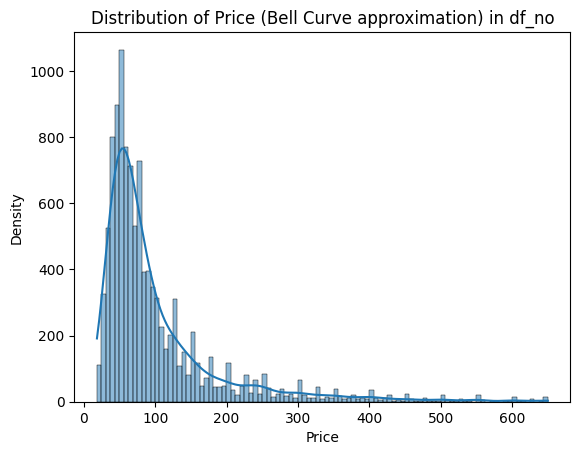

In [86]:
sns.histplot(df_new['price'], kde=True)
plt.title('Distribution of Price (Bell Curve approximation) in df_no')
plt.xlabel('Price')
plt.ylabel('Density')